=== Тест 1: Тривиальный случай (α=0, f=g=0) ===
Случай alpha=0, решается линейная система.
Погрешность (норма невязки): 0.00e+00


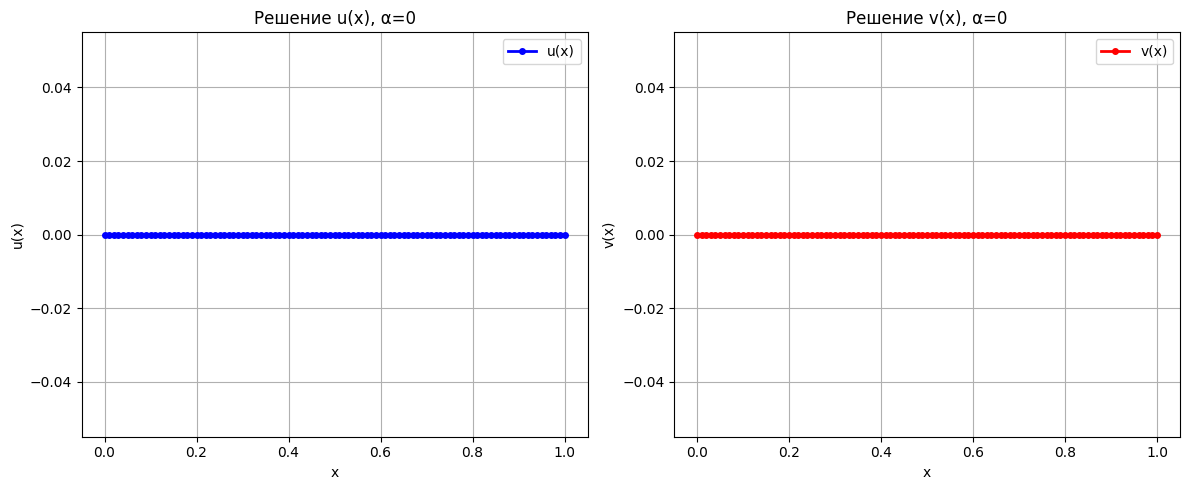


=== Тест 2: f = 2, g = 1, alpha = 0, N = 10
Случай alpha=0, решается линейная система.


IndexError: index 11 is out of bounds for axis 0 with size 11

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

class NonlinearSystemSolver:
    def __init__(self, N, alpha, f, g):
        self.N = N
        self.h = 1.0 / N
        self.alpha = alpha
        self.f = f
        self.g = g
        # Сетка узлов
        self.x = np.linspace(0, 1, N + 1)
        
        # Неизвестные: u_1..u_{N} (N штук), v_0..v_{N-1} (N штук)
        # Всего 2*N неизвестных
        self.num_unknowns = 2 * N

    def _Q(self, u, v):
        """Нелинейный член."""
        denominator = u**2 + v**2 + 1e-8
        #if np.abs(denominator) < 1e-12:
        #    return 0.0
        return self.alpha * u * v / denominator

    def _dQ_du(self, u, v):
        """Частная производная нелинейного члена по u."""
        denominator = u**2 + v**2 + 1e-8
        #if np.abs(denominator) < 1e-12:
        #    return 0.0
        return self.alpha * v * (v**2 + 1e-8 - u**2) / (denominator**2)

    def _dQ_dv(self, u, v):
        """Частная производная нелинейного члена по v."""
        denominator = u**2 + v**2
        if np.abs(denominator) < 1e-12:
            return 0.0
        return self.alpha * u * (u**2 + 1e-8 - v**2) / (denominator**2)
    
    def build_F_vector(self, u_vec, v_vec):
        """
        Собирает вектор невязок F размером 2N.
        u_vec: [u_0, u_1, ..., u_N] (N+1 элемент)
        v_vec: [v_0, v_1, ..., v_N] (N+1 элемент)
        """
        F = np.zeros(self.num_unknowns)
        
        # Уравнения для u (индексы 0 to N-1 в векторе F)
        for i in range(1, self.N):  # i = 1, 2, ..., N-1
            # F[i-1] соответствует уравнению в узле x_i
            term_u_xx = u_vec[i-1] - 2*u_vec[i] + u_vec[i+1]
            nonlin_term = self.h**2 * self._Q(u_vec[i], v_vec[i])
            f_term = self.h**2 * self.f(self.x[i])
            F[i-1] = term_u_xx - nonlin_term + f_term

        # Граничное условие u'(1)=0 (второй порядок)
        # 3*u_N - 4*u_{N-1} + u_{N-2} = 0
        if self.N >= 2:
            F[self.N-1] = 3*u_vec[self.N] - 4*u_vec[self.N-1] + u_vec[self.N-2]
        
        # Уравнения для v (индексы N to 2N-1 в векторе F)
        # Уравнение в узле x_0
        if self.N >= 2:
            F[self.N] = -3*v_vec[0] + 4*v_vec[1] - v_vec[2] - 2*self.h*self.g(self.x[0])

        # Уравнения для внутренних узлов i от 1 до N-1
        for i in range(1, self.N):
            # F[N+i] соответствует уравнению в узле x_i
            term_v_x = v_vec[i+1] - v_vec[i-1]
            nonlin_term = 2*self.h * self._Q(u_vec[i], v_vec[i])
            g_term = 2*self.h * self.g(self.x[i])
            F[self.N + i] = term_v_x - nonlin_term - g_term
        
        return F
        
    def build_jacobian_matrix(self, u_vec, v_vec):
        """
        Собирает матрицу Якоби J размером 2N x 2N.
        """
        J = np.zeros((self.num_unknowns, self.num_unknowns))
        
        # --- Блок производных уравнений u по переменным ---
        # (строки 0 to N-1)
        
        # по u_j
        for i in range(1, self.N):
            row = i - 1
            # dF_i/du_{i-1}
            if i > 1: 
                J[row, i-2] = 1
            # dF_i/du_i
            J[row, i-1] = -2 - self.h**2 * self._dQ_du(u_vec[i], v_vec[i])
            # dF_i/du_{i+1}
            if i < self.N: 
                J[row, i] = 1
        
        # Граничное условие u'(1)=0
        if self.N >= 2:
            row = self.N - 1
            if self.N >= 3:
                J[row, self.N-3] = 1   # по u_{N-2}
            J[row, self.N-2] = -4  # по u_{N-1}
            J[row, self.N-1] = 3   # по u_N

        # по v_j
        for i in range(1, self.N):
            row = i - 1
            col = self.N + i - 1  # исправлено: v_{i} соответствует столбцу N + i - 1
            J[row, col] = -self.h**2 * self._dQ_dv(u_vec[i], v_vec[i])

        # --- Блок производных уравнений v по переменным ---
        # (строки N to 2N-1)
        
        # по u_j
        for i in range(1, self.N):
            row = self.N + i - 1  # исправлено
            col = i - 1 # столбец для u_i
            J[row, col] = -2 * self.h * self._dQ_du(u_vec[i], v_vec[i])
            
        # по v_j
        # Уравнение в узле x_0
        if self.N >= 2:
            row = self.N
            J[row, self.N] = -3    # по v_0
            if self.N + 1 < self.num_unknowns:
                J[row, self.N+1] = 4     # по v_1
            if self.N + 2 < self.num_unknowns:
                J[row, self.N+2] = -1    # по v_2

        # Внутренние узлы
        for i in range(1, self.N):
            row = self.N + i - 1  # исправлено
            if self.N + i - 2 >= self.N:  # v_{i-1}
                J[row, self.N + i - 2] = -1
            J[row, self.N + i - 1] = -2*self.h * self._dQ_dv(u_vec[i], v_vec[i])
            if self.N + i < self.num_unknowns:  # v_{i+1}
                J[row, self.N + i] = 1
        
        return J

    def solve(self, max_iter=50, tol=1e-8):
        """Решение системы нелинейных уравнений методом Ньютона."""
        
        # Для случая α=0 решаем отдельно как линейную систему
        if abs(self.alpha) < 1e-12:
            print("Случай alpha=0, решается линейная система.")
            return self.solve_linear_case()
        
        # Начальное приближение
        X = np.zeros(self.num_unknowns)
        # Начальное приближение для u: u_i = x_i * (1 - x_i)
        for i in range(self.N):
            x_val = (i + 1) * self.h  # x_i для u_i
            X[i] = x_val * (1 - x_val)
        # Начальное приближение для v: v_i = 1 - x_i
        for i in range(self.N):
            x_val = i * self.h  # x_i для v_i
            X[self.N + i] = 1 - x_val
        
        print("Начало итераций методом Ньютона...")
        for iteration in range(max_iter):
            # Формируем полные векторы u и v
            u = np.zeros(self.N + 1)
            v = np.zeros(self.N + 1)
            
            u[0] = 0  # u(0) = 0
            u[1:] = X[:self.N]  # u_1..u_N
            
            v[:self.N] = X[self.N:]  # v_0..v_{N-1}
            v[self.N] = 0  # v(1) = 0
            
            # 1. Вычисляем вектор невязок F(X_k)
            F = self.build_F_vector(u, v)
            
            # 2. Вычисляем матрицу Якоби J(X_k)
            J = self.build_jacobian_matrix(u, v)
            
            # 3. Решаем СЛАУ J * delta_X = -F
            try:
                delta_X = np.linalg.solve(J, -F)
            except np.linalg.LinAlgError:
                print("Ошибка: матрица Якоби вырождена. Используем псевдообратную.")
                delta_X = -np.linalg.pinv(J) @ F

            # 4. Обновляем вектор решения
            X += delta_X
            
            # 5. Проверяем сходимость
            norm = np.linalg.norm(delta_X)
            print(f"Итерация {iteration+1}: Норма поправки = {norm:.2e}")
            
            if norm < tol:
                print(f"Сходимость достигнута на итерации {iteration+1}")
                break
        else:
            print("Достигнуто максимальное число итераций")

        # Финальное формирование векторов
        u_final = np.zeros(self.N + 1)
        v_final = np.zeros(self.N + 1)
        
        u_final[0] = 0
        u_final[1:] = X[:self.N]
        
        v_final[:self.N] = X[self.N:]
        v_final[self.N] = 0

        return u_final, v_final
    
    def solve_linear_case(self):
        """Решение для случая α=0"""
        u = np.zeros(self.N+1)
        v = np.zeros(self.N+1)
        
        # Решаем уравнение для u: -u'' = f(x)
        A_u = np.zeros((self.N+1, self.N+1))
        b_u = np.zeros(self.N+1)
        
        for i in range(1, self.N):
            A_u[i, i-1] = 1
            A_u[i, i] = -2
            A_u[i, i+1] = 1
            b_u[i] = -self.h**2 * self.f(self.x[i])
        
        A_u[0, 0] = 1
        b_u[0] = 0
        
        A_u[self.N, self.N-1] = -1
        A_u[self.N, self.N] = 1
        b_u[self.N] = 0
        
        u = np.linalg.solve(A_u, b_u)
        
        # Решаем уравнение для v: v' = g(x)
        A_v = np.zeros((self.N+1, self.N+1))
        b_v = np.zeros(self.N+1)
        
        for i in range(self.N):
            A_v[i, i] = -1/self.h
            A_v[i, i+1] = 1/self.h
            b_v[i] = self.g(self.x[i])
        
        A_v[self.N, self.N] = 1
        b_v[self.N] = 0
        
        v = np.linalg.solve(A_v, b_v)
        
        return u, v
    
    def visualize(self, u, v, p=0):
        """Визуализация результатов"""
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(self.x, u, 'b-o', linewidth=2, markersize=4, label='u(x)')
        plt.xlabel('x')
        plt.ylabel('u(x)')
        plt.title(f'Решение u(x), α={self.alpha}')
        plt.grid(True)
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(self.x, v, 'r-o', linewidth=2, markersize=4, label='v(x)')
        plt.xlabel('x')
        plt.ylabel('v(x)')
        plt.title(f'Решение v(x), α={self.alpha}')
        plt.grid(True)
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    def calculate_residuals_norm(self, u, v):
        """Вычисление нормы невязки для оценки погрешности решения."""
        F = self.build_F_vector(u, v)
        return np.linalg.norm(F)


# Тестирование
if __name__ == "__main__":
    print("=== Тест 1: Тривиальный случай (α=0, f=g=0) ===")
    N = 100
    alpha = 0
    
    def f(x):
        return 0
    
    def g(x):
        return 0
    
    solver = NonlinearSystemSolver(N, alpha, f, g)
    u, v = solver.solve()
    error = solver.calculate_residuals_norm(u, v)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver.visualize(u, v)

    print("\n=== Тест 2: f = 2, g = 1, alpha = 0, N = 10")
    def f1(x):
        return 2.0

    def g1(x):
        return 1.0

    solver1 = NonlinearSystemSolver(10, 0.0, f1, g1)
    u1, v1 = solver1.solve()
    error = solver.calculate_residuals_norm(u1, v1)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver1.visualize(u1, v1, p = 1)

    print("\n=== Тест 3: f = 2, g = 1, alpha = 0, N = 150")
    def f1(x):
        return 2.0

    def g1(x):
        return 1.0

    solver1 = NonlinearSystemSolver(150, 0.0, f1, g1)
    u1, v1 = solver1.solve()
    error = solver.calculate_residuals_norm(u1, v1)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver1.visualize(u1, v1, p = 1)

    print("\n=== Тест 4: f = 2, g = 1, alpha = 0.2, N = 150")
    def f1(x):
        return 2.0

    def g1(x):
        return 1.0

    solver1 = NonlinearSystemSolver(150, 0.2, f1, g1)
    u1, v1 = solver1.solve()
    error = solver.calculate_residuals_norm(u1, v1)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver1.visualize(u1, v1)

    print("\n=== Тест 5: f = 2, g = 1, alpha = 0.8, N = 150")
    def f1(x):
        return 2.0

    def g1(x):
        return 1.0

    solver1 = NonlinearSystemSolver(150, 0.8, f1, g1)
    u1, v1 = solver1.solve()
    error = solver.calculate_residuals_norm(u1, v1)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver1.visualize(u1, v1)

    print("\n=== Тест 6: f = 2, g = 1, alpha = 5, N = 150")
    def f1(x):
        return 2.0

    def g1(x):
        return 1.0

    solver1 = NonlinearSystemSolver(150, 5.0, f1, g1)
    u1, v1 = solver1.solve()
    error = solver.calculate_residuals_norm(u1, v1)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver1.visualize(u1, v1)

    print("\n=== Тест 7: f = 20, g = 10, alpha = 0, N = 150")
    def f1(x):
        return 20.0

    def g1(x):
        return 10.0

    solver1 = NonlinearSystemSolver(150, 0.0, f1, g1)
    u1, v1 = solver1.solve()
    error = solver.calculate_residuals_norm(u1, v1)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver1.visualize(u1, v1, p = 2)

    print("\n=== Тест 8: f = -20, g = -10, alpha = 0, N = 150")
    def f1(x):
        return -20.0

    def g1(x):
        return -10.0

    solver1 = NonlinearSystemSolver(150, 0.0, f1, g1)
    u1, v1 = solver1.solve()
    error = solver.calculate_residuals_norm(u1, v1)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver1.visualize(u1, v1, p = 3)

    print("\n=== Тест 2: Тригонометрические правые части ===")
    def f1(x):
        return 2.0 * np.sin(2*np.pi*x) + 0.5*x

    def g1(x):
        return 1.5 * np.cos(np.pi*x) * (1-x)

    solver1 = NonlinearSystemSolver(50, 0.8, f1, g1)
    u1, v1 = solver1.solve()
    error = solver.calculate_residuals_norm(u1, v1)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver1.visualize(u1, v1)

    print("\n=== Тест 3: Полиномиальные правые части ===")
    def f2(x):
        return 3*x*(1-x)**2

    def g2(x):
        return 2*(1-x)**3

    solver2 = NonlinearSystemSolver(50, 0.6, f2, g2)
    u2, v2 = solver2.solve()
    error = solver.calculate_residuals_norm(u2, v2)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver2.visualize(u2, v2)

    print("\n=== Тест 4: Экспоненциальные правые части ===")
    def f3(x):
        return 1.5 * (np.exp(-2*x) - np.exp(-2))

    def g3(x):
        return 2.0 * np.exp(-3*x) * (1-x)

    solver3 = NonlinearSystemSolver(50, 0.4, f3, g3)
    u3, v3 = solver3.solve()
    error = solver.calculate_residuals_norm(u3, v3)
    print(f"Погрешность (норма невязки): {error:.2e}")
    solver3.visualize(u3, v3)

    print("\n=== Тест 5: Исследование влияния α ===")
    alphas = [0, 0.2, 0.5, 1.0, 2.0]
    
    plt.figure(figsize=(15, 10))
    for i, alpha in enumerate(alphas):
        solver_alpha = NonlinearSystemSolver(50, alpha, f2, g2)
        u_alpha, v_alpha = solver_alpha.solve()
        
        plt.subplot(2, 3, i+1)
        plt.plot(solver_alpha.x, u_alpha, 'b-', label=f'u(x), α={alpha}')
        plt.plot(solver_alpha.x, v_alpha, 'r-', label=f'v(x), α={alpha}')
        plt.xlabel('x')
        plt.ylabel('Значения')
        plt.title(f'Решения при α={alpha}')
        plt.grid(True)
        plt.legend()
    
    plt.tight_layout()
    plt.show()


=== Тест 1: Полиномиальные f, g ===
Начало итераций методом Ньютона...
Итерация 1: Норма поправки = 7.81e-01
Итерация 2: Норма поправки = 1.51e-03
Итерация 3: Норма поправки = 4.99e-09
Сходимость достигнута на итерации 3
Начало итераций методом Ньютона...
Итерация 1: Норма поправки = 6.32e+00
Итерация 2: Норма поправки = 6.77e-01
Итерация 3: Норма поправки = 2.64e-02
Итерация 4: Норма поправки = 1.36e-05
Итерация 5: Норма поправки = 3.01e-12
Сходимость достигнута на итерации 5
Начало итераций методом Ньютона...
Итерация 1: Норма поправки = 8.90e+01
Итерация 2: Норма поправки = 8.91e+01
Итерация 3: Норма поправки = 2.32e+01
Итерация 4: Норма поправки = 2.02e+01
Итерация 5: Норма поправки = 1.18e+01
Итерация 6: Норма поправки = 8.97e+00
Итерация 7: Норма поправки = 5.88e+00
Итерация 8: Норма поправки = 4.28e+00
Итерация 9: Норма поправки = 2.89e+00
Итерация 10: Норма поправки = 2.05e+00
Итерация 11: Норма поправки = 1.40e+00
Итерация 12: Норма поправки = 9.84e-01
Итерация 13: Норма попр

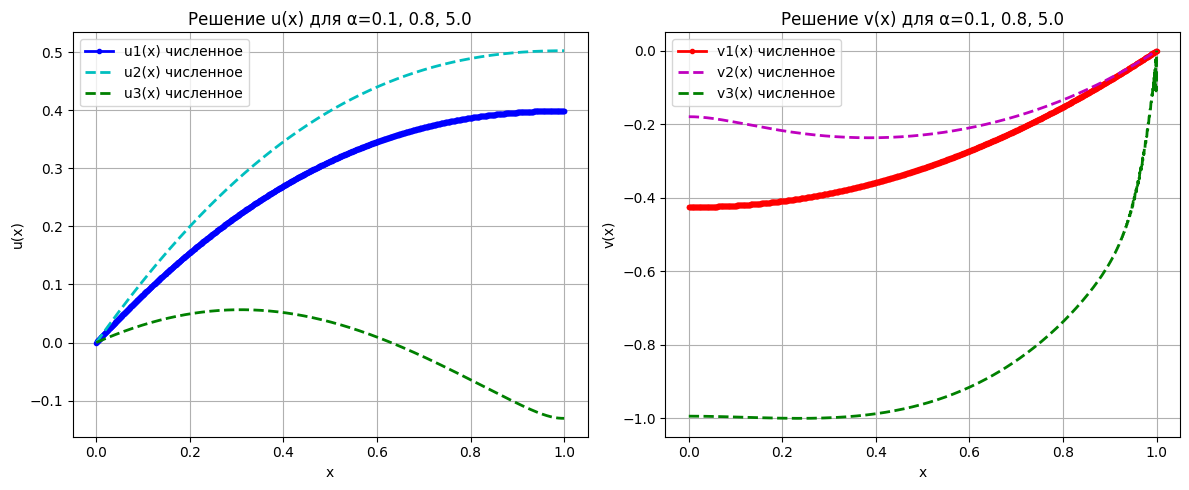

In [39]:
import numpy as np
import matplotlib.pyplot as plt

class NonlinearSystemSolver:
    def __init__(self, N, alpha, f, g):
        self.N = N
        self.h = 1.0 / N
        self.alpha = alpha
        self.f = f
        self.g = g
        # Сетка узлов
        self.x = np.linspace(0, 1, N + 1)
        
        # Неизвестные: u_1..u_N (N штук), v_0..v_{N-1} (N штук)
        # Всего 2*N неизвестных
        self.num_unknowns = 2 * N

    def _Q(self, u, v):
        """Нелинейный член. Добавляем малое число для стабильности."""
        denominator = u**2 + v**2 + 1e-8
        # Избегаем деления на ноль
        #if np.abs(denominator) < 1e-12:
        #   return 0.0
        return self.alpha * u * v / denominator

    def _dQ_du(self, u, v):
        """Частная производная нелинейного члена по u."""
        denominator = u**2 + v**2 + 1e-8
        #if np.abs(denominator) < 1e-12:
        #    return 0.0
        return self.alpha * v * (v**2 + 1e-8 - u**2) / (denominator**2)

    def _dQ_dv(self, u, v):
        """Частная производная нелинейного члена по v."""
        denominator = u**2 + v**2 + 1e-8
        #if np.abs(denominator) < 1e-12:
        #    return 0.0
        return self.alpha * u * (u**2 + 1e-8 - v**2) / (denominator**2)
    
    def build_F_vector(self, u_vec, v_vec):
        """
        Собирает вектор невязок F размером 2N.
        u_vec: [u_0, u_1, ..., u_N]
        v_vec: [v_0, v_1, ..., v_N]
        """
        F = np.zeros(self.num_unknowns)
        
        # Уравнения для u (индексы 0 to N-1 в векторе F)
        for i in range(1, self.N):
            term_u_xx = u_vec[i-1] - 2*u_vec[i] + u_vec[i+1]
            nonlin_term = self.h**2 * self._Q(u_vec[i], v_vec[i])
            f_term = self.h**2 * self.f(self.x[i])
            F[i-1] = term_u_xx - nonlin_term + f_term

        # Граничное условие u'(1)=0 (второй порядок)
        F[self.N-1] = 3*u_vec[self.N] - 4*u_vec[self.N-1] + u_vec[self.N-2]
        
        # Уравнения для v (индексы N to 2N-1 в векторе F)
        # Уравнение в узле x_0
        F[self.N] = -3*v_vec[0] + 4*v_vec[1] - v_vec[2] - 2*self.h*self.g(self.x[0])
        
        # Уравнения для внутренних узлов i от 1 до N-1
        for i in range(1, self.N):
            term_v_x = v_vec[i+1] - v_vec[i-1]
            nonlin_term = 2*self.h * self._Q(u_vec[i], v_vec[i])
            g_term = 2*self.h * self.g(self.x[i])
            F[self.N + i] = term_v_x - nonlin_term - g_term
        
        return F
        
    def build_jacobian_matrix(self, u_vec, v_vec):
        """
        Собирает матрицу Якоби J размером 2N x 2N.
        """
        J = np.zeros((self.num_unknowns, self.num_unknowns))
        
        # --- Блок производных уравнений u по переменным u_j ---
        for i in range(1, self.N):
            row = i - 1
            if i > 1: J[row, i-2] = 1 # по u_{i-1}
            J[row, i-1] = -2 - self.h**2 * self._dQ_du(u_vec[i], v_vec[i]) # по u_i
            J[row, i] = 1 # по u_{i+1}
        
        # Граничное условие u'(1)=0
        row = self.N - 1
        J[row, self.N-3] = 1   # по u_{N-2}
        J[row, self.N-2] = -4  # по u_{N-1}
        J[row, self.N-1] = 3   # по u_N

        # --- Блок производных уравнений u по переменным v_j ---
        for i in range(1, self.N):
            row = i - 1
            col = self.N + i # столбец для v_i
            J[row, col] = -self.h**2 * self._dQ_dv(u_vec[i], v_vec[i])

        # --- Блок производных уравнений v по переменным u_j ---
        for i in range(1, self.N):
            row = self.N + i
            col = i-1 # столбец для u_i (т.к. u_1 - первая переменная)
            J[row, col] = -2 * self.h * self._dQ_du(u_vec[i], v_vec[i])
            
        # --- Блок производных уравнений v по переменным v_j ---
        # Уравнение в узле x_0
        row = self.N
        J[row, self.N] = -3    # по v_0
        J[row, self.N+1] = 4     # по v_1
        J[row, self.N+2] = -1    # по v_2

        # Внутренние узлы
        for i in range(1, self.N):
            row = self.N + i
            J[row, self.N + i - 1] = -1 # по v_{i-1}
            J[row, self.N + i] = -2*self.h * self._dQ_dv(u_vec[i], v_vec[i]) # по v_i
            if i < self.N - 1:
                J[row, self.N + i + 1] = 1 # по v_{i+1}
        
        return J

    def solve(self, max_iter=100, tol=1e-8, verbose=True):
        """Решение системы нелинейных уравнений методом Ньютона."""
        if abs(self.alpha) < 1e-12:
            if verbose: print("Случай alpha=0, решается как линейная система.")
            return self.solve_linear_case()
        
        # Начальное приближение (решение лин. задачи - хороший старт)
        u_lin, v_lin = self.solve_linear_case()
        X = np.concatenate([u_lin[1:], v_lin[:-1]])
        
        if verbose: print("Начало итераций методом Ньютона...")
        for iteration in range(max_iter):
            u = np.zeros(self.N + 1)
            v = np.zeros(self.N + 1)
            
            u[1:] = X[:self.N]
            v[:-1] = X[self.N:]
            
            F = self.build_F_vector(u, v)
            J = self.build_jacobian_matrix(u, v)
            
            try:
                delta_X = np.linalg.solve(J, -F)
            except np.linalg.LinAlgError:
                if verbose: print("Ошибка: матрица Якоби вырождена. Метод не может продолжаться.")
                return u, v # Возвращаем последнее успешное приближение

            X += delta_X
            norm = np.linalg.norm(delta_X)
            if verbose: print(f"Итерация {iteration+1}: Норма поправки = {norm:.2e}")
            
            if norm < tol:
                if verbose: print(f"Сходимость достигнута на итерации {iteration+1}")
                break
        else:
             if verbose: print("Достигнуто максимальное число итераций, сходимость не достигнута.")

        u_final = np.zeros(self.N + 1)
        v_final = np.zeros(self.N + 1)
        u_final[1:] = X[:self.N]
        v_final[:-1] = X[self.N:]
        
        return u_final, v_final
    
    def solve_linear_case(self):
        """Решение для случая α=0"""
        u = np.zeros(self.N+1)
        A_u = np.zeros((self.N, self.N))
        b_u = np.zeros(self.N)

        # Решаем для u_1, ..., u_N
        for i in range(1, self.N):
            # Уравнение для u_i
            row = i - 1
            # u_{i-1}
            if i > 1: A_u[row, i-2] = 1
            # u_i
            A_u[row, i-1] = -2
            # u_{i+1}
            A_u[row, i] = 1
            b_u[row] = -self.h**2 * self.f(self.x[i])
    
        # ГУ u'(1)=0 -> 3*u_N - 4*u_{N-1} + u_{N-2} = 0
        A_u[self.N-1, self.N-3] = 1
        A_u[self.N-1, self.N-2] = -4
        A_u[self.N-1, self.N-1] = 3
        b_u[self.N-1] = 0

        u_part = np.linalg.solve(A_u, b_u)
        u[1:] = u_part
    
        v = np.zeros(self.N+1)
        # ПРАВИЛЬНОЕ интегрирование v' = g(x) с v(1)=0
        # v(x) = -∫_x^1 g(t) dt
        # Используем метод трапеций для большей точности
        v[self.N] = 0  # v(1) = 0
        for i in range(self.N-1, -1, -1):
            # Интеграл от x_i до 1: v(x_i) = -∫_{x_i}^1 g(t) dt
            # Используем составное правило трапеций
            integral = 0.0
            for j in range(i, self.N):
                integral += (self.g(self.x[j]) + self.g(self.x[j+1])) * self.h / 2
            v[i] = -integral
    
        return u, v

    def calculate_residuals_norm(self, u, v):
        """Вычисление нормы невязки для оценки погрешности решения."""
        F = self.build_F_vector(u, v)
        return np.linalg.norm(F)

    def calculate_exact_solution_error(self, u_num1, v_num1, u_num2, v_num2):
        """
        Вычисление погрешности между численным и точным решением.
        
        Parameters:
        u_num, v_num - численные решения
        
        Returns:
        error_u, error_v - погрешности для u и v в норме L2
        max_error_u, max_error_v - максимальные погрешности для u и v
        """
        # Точные решения
        #u_exact = np.sin(np.pi * self.x /2)
        #v_exact = np.sin(np.pi * self.x )
        
        # Погрешности в норме L2
        error_u = np.sqrt(self.h * np.sum((u_num1 - u_num2)**2))
        error_v = np.sqrt(self.h * np.sum((v_num1 - v_num2)**2))
        
        # Максимальные погрешности
        max_error_u = np.max(np.abs(u_num1 - u_num2))
        max_error_v = np.max(np.abs(v_num1 - v_num2))
        
        return max(max_error_u, max_error_v)

    def visualize(self, u1, v1, u2, v2, u3, v3, title_suffix=""):
        """Визуализация результатов с эталонными функциями"""
        plt.figure(figsize=(12, 5))
    
    
        # График u(x) - левая панель
        plt.subplot(1, 2, 1)
        plt.plot(self.x, u1, 'b-o', linewidth=2, markersize=3, label='u1(x) численное')
        plt.plot(self.x, u2, 'c--', linewidth=2, label='u2(x) численное')
        plt.plot(self.x, u3, 'g--', linewidth=2, label='u3(x) численное')
        plt.xlabel('x')
        plt.ylabel('u(x)')
        plt.title(f'Решение u(x) {title_suffix}')
        plt.grid(True)
        plt.legend()
    
        # График v(x) - правая панель
        plt.subplot(1, 2, 2)
        plt.plot(self.x, v1, 'r-o', linewidth=2, markersize=3, label='v1(x) численное')
        plt.plot(self.x, v2, 'm--', linewidth=2, label='v2(x) численное')
        plt.plot(self.x, v3, 'g--', linewidth=2, label='v3(x) численное')
        plt.xlabel('x')
        plt.ylabel('v(x)')
        plt.title(f'Решение v(x) {title_suffix}')
        plt.grid(True)
        plt.legend()
    
        plt.tight_layout()
        plt.show()



# --- Основной блок для выполнения тестов ---
if __name__ == "__main__":
    N_main = 1000 # Основное число узлов для тестов
    
    # === Тест 1: Полиномиальные функции ===
    print("\n=== Тест 1: Полиномиальные f, g ===")
    def f_poly(x): return np.cos(x)
    def g_poly(x): return np.sin(x)
    
    solver = NonlinearSystemSolver(N_main, 0.1, f_poly, g_poly)
    u1, v1 = solver.solve()
    solver = NonlinearSystemSolver(N_main, 0.8, f_poly, g_poly)
    u2, v2 = solver.solve()
    solver = NonlinearSystemSolver(N_main, 5.0, f_poly, g_poly)
    u3, v3 = solver.solve()
    solver.visualize(u1, v1, u2, v2, u3, v3, title_suffix=f'для α=0.1, 0.8, 5.0')
    